In [2]:
!pip install scikit-learn


     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------------------- ------ 51.2/60.8 kB 518.5 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/60.8 kB 518.5 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 294.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.4/8.7 MB 11.6 MB/s eta 0:00:01
   --- ------------------------------------ 0.7/8.7 MB 8.3 MB/s eta 0:00:01
   ---- ----------------------------------- 1.0/8.7 MB 9.3 MB/s eta 0:00:01
   ----- ---------------------------------- 1.1/8.7 MB 8.0 MB/s eta 0:00:01
   ----- ---------------------------------- 1.1/8.7 MB 8.0 MB/s eta 0:00:01
   ----- ---------------------------------- 1.2/8.7 MB 5.7 MB/s eta 0:00:02
   -------- -----


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install xgboost


   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB 495.5 kB/s eta 0:01:55
   ---------------------------------------- 0.1/56.8 MB 1.4 MB/s eta 0:00:40
   ---------------------------------------- 0.2/56.8 MB 1.6 MB/s eta 0:00:36
   ---------------------------------------- 0.2/56.8 MB 1.6 MB/s eta 0:00:36
   ---------------------------------------- 0.7/56.8 MB 2.6 MB/s eta 0:00:22
    --------------------------------------- 1.0/56.8 MB 3.3 MB/s eta 0:00:17
    --------------------------------------- 1.2/56.8 MB 3.7 MB/s eta 0:00:16
   - -------------------------------------- 1.5/56.8 MB 3.9 MB/s eta 0:00:15
   - -------------------------------------- 1.8/56.8 MB 4.2 MB/s eta 0:00:14
   - -------------------------------------- 2.0/56.8 MB 4.4 MB/s eta 0:00:13
   - -------------------------------------- 2.2/56.8 MB 4.4 MB/s eta 0:00:13
   - ------


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae

import warnings
warnings.filterwarnings('ignore')

# Loading the dataset into a pandas DataFrame

In [19]:
df = pd.read_csv(r'C:\Users\HP\Desktop\JupyterProjects\StoreDemand.csv')
display(df.head(5))


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


# Shape

In [20]:
df.shape

(913000, 4)

# checking data type

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


# describing data frame 

In [22]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


# Feature Engineering

In [23]:
parts = df["date"].str.split("-", n = 3, expand = True)
df["year"]= parts[0].astype('int')
df["month"]= parts[1].astype('int')
df["day"]= parts[2].astype('int')
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


In [24]:
# Basically here we are adding a column Weenkend which takes its value from given below function.
from datetime import datetime

def weekend_or_weekday(year, month, day):
    d = datetime(year, month, day)
    return 1 if d.weekday() > 4 else 0 # d.weekday() returns 0 to 6 integer 

df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)

In [26]:
!pip install holidays


     ---------------------------------------- 0.0/48.8 kB ? eta -:--:--
     ---------------- ----------------------- 20.5/48.8 kB ? eta -:--:--
     ---------------- ----------------------- 20.5/48.8 kB ? eta -:--:--
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/48.8 kB 217.9


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# a column which can indicate whether there was any holiday on a particular day or not.
from datetime import date
import holidays

india_holidays = holidays.country_holidays('IN')
df['holidays'] = df['date'].apply(lambda x: 1 if india_holidays.get(x) else 0)

In [ ]:
# let's add some cyclical features.
#Months (1–12) are cyclical:
#December (12) is closer to January (1) than to June (6).
#But a plain numeric scale doesn't capture that — it treats them as far apart (12 and 1 are 11 units apart numerically).
#Using sine and cosine turns the months into points on a circle, preserving their cyclic nature.

In [28]:
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))
df.head(5)

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2
0,2013-01-01,1,1,13,2013,1,1,0,0,0.5,0.866025
1,2013-01-02,1,1,11,2013,1,2,0,0,0.5,0.866025
2,2013-01-03,1,1,14,2013,1,3,0,0,0.5,0.866025
3,2013-01-04,1,1,13,2013,1,4,0,0,0.5,0.866025
4,2013-01-05,1,1,10,2013,1,5,1,0,0.5,0.866025


In [29]:
# Let's have a column whose value indicates which day of the week it is.
def which_day(year, month, day):
    return datetime(year, month, day).weekday()

df['weekday'] = df.apply(lambda x: which_day(x['year'], x['month'], x['day']), axis=1)

In [30]:
# remove the columns which are not useful for us.
df.drop('date', axis=1, inplace=True)

# Exploratory Data Analysis

In [31]:
# let's check the unique values in the store and item column using nunique().
df['store'].nunique(), df['item'].nunique()

(10, 50)

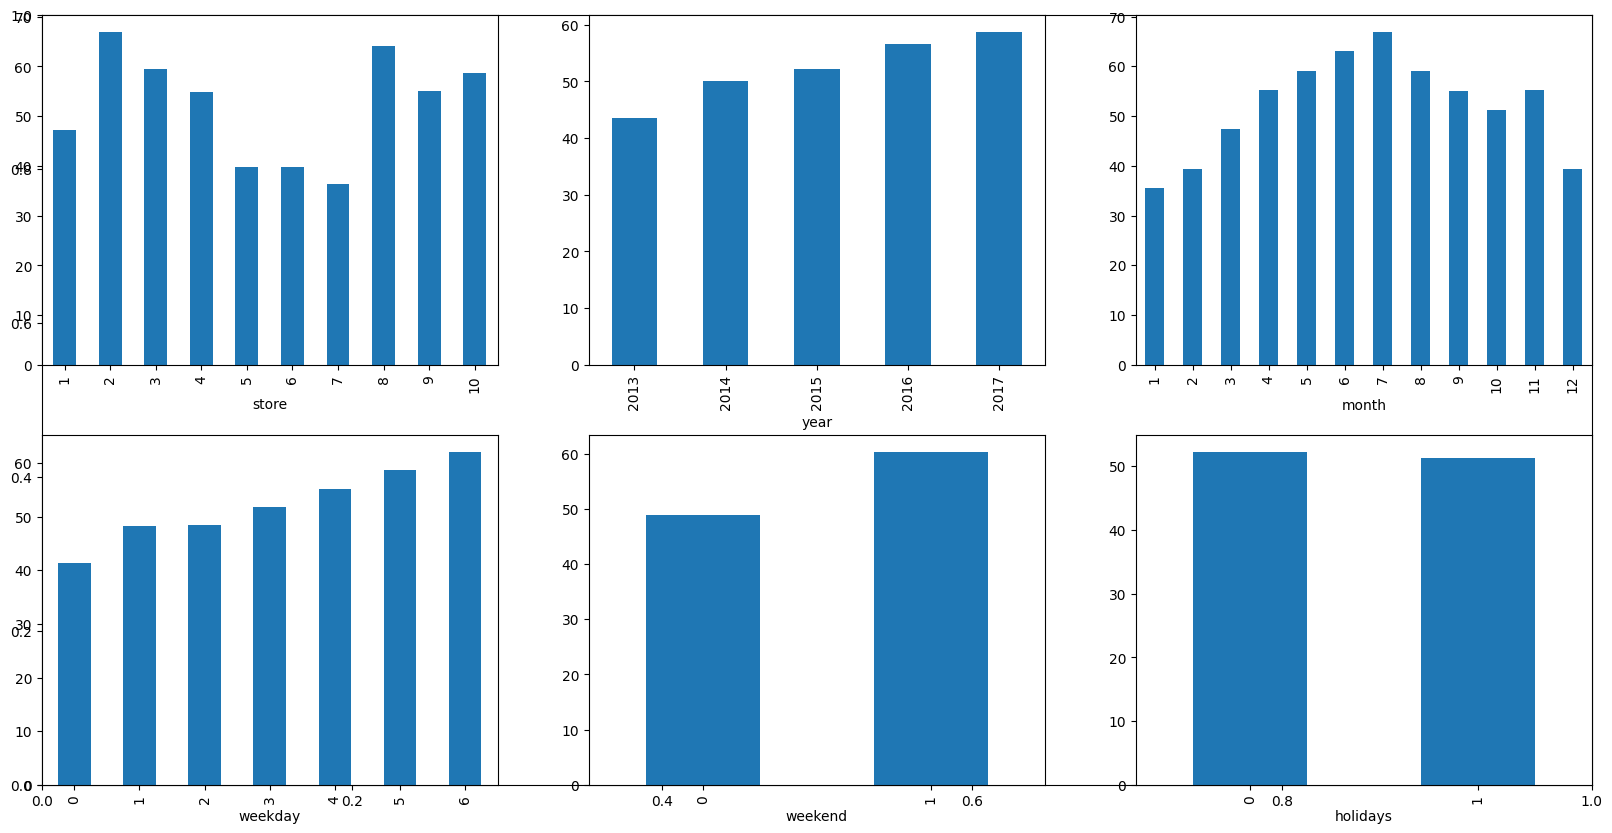

In [32]:
# let's analyze the relationship between various features and sales performance by visualizing.
df['weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['sales'].plot.bar()
plt.show()

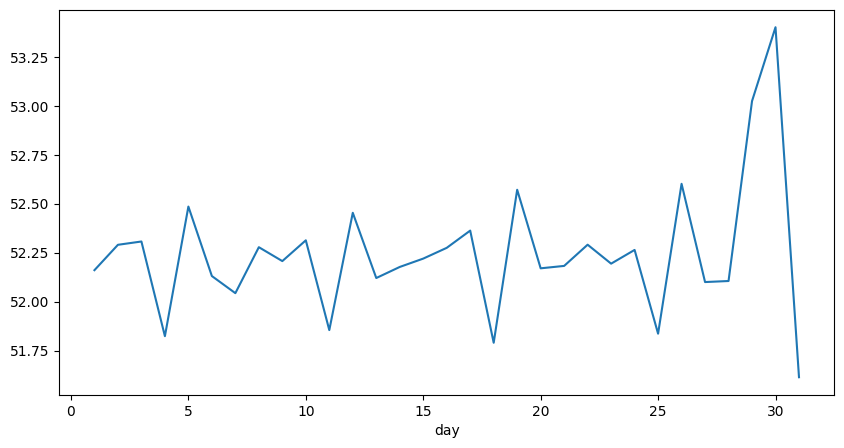

In [33]:
# let's check the variation of stock as the month closes to the end using line plot.
plt.figure(figsize=(10,5))
df.groupby('day').mean()['sales'].plot()
plt.show()

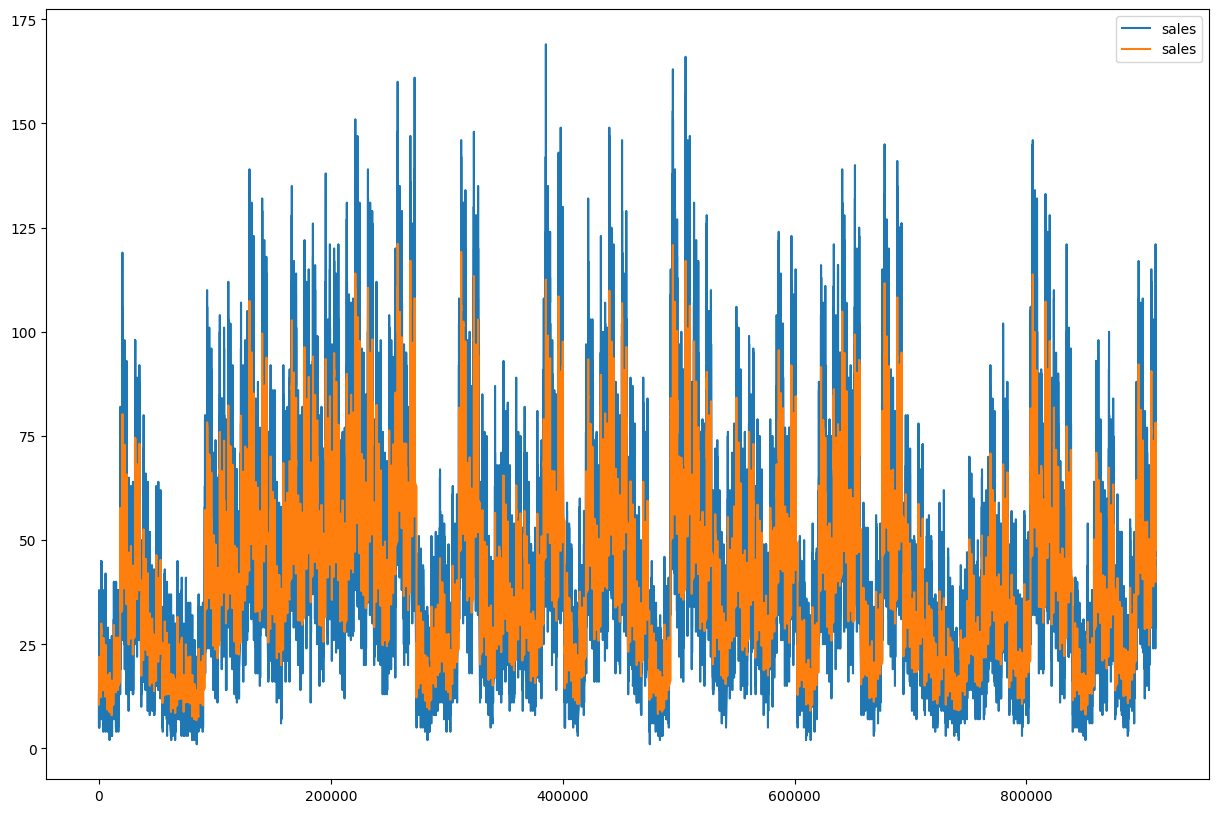

In [34]:
# Let's draw the simple moving average for 30 days period. Plotting simple moving average with help to smooth out short-term fluctuations and highlight longer-term trend or cycles in the data.
plt.figure(figsize=(15, 10))

# Calculating Simple Moving Average 
# for a window period of 30 days
window_size = 30
data = df[df['year']==2013]
windows = data['sales'].rolling(window_size)
sma = windows.mean()
sma = sma[window_size - 1:]

data['sales'].plot()
sma.plot()
plt.legend()
plt.show()

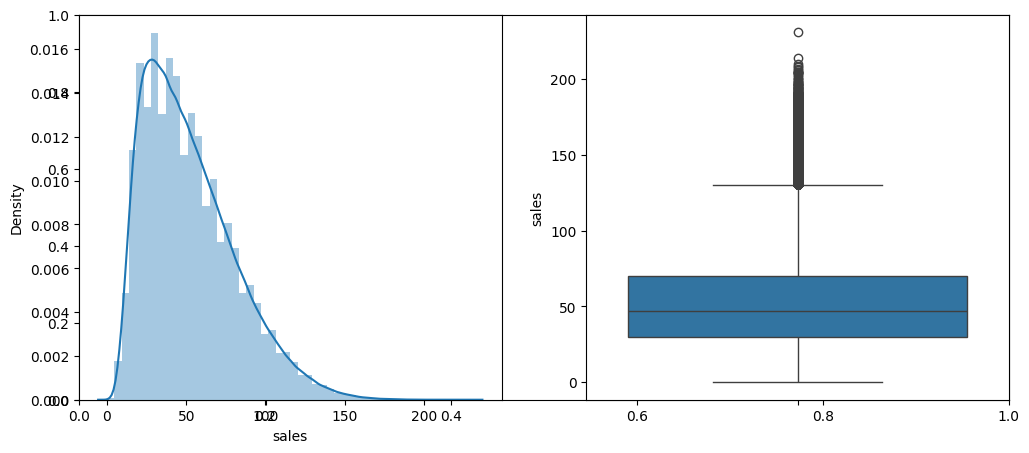

In [35]:
# As the data in the sales column is continuous let's check the distribution of it and check whether there are some outliers in this column or not. For this we are using distplot and boxplot.
plt.subplots(figsize=(12, 5))
plt.subplot(1, 2, 1)
sb.distplot(df['sales'])

plt.subplot(1, 2, 2)
sb.boxplot(df['sales'])
plt.show()

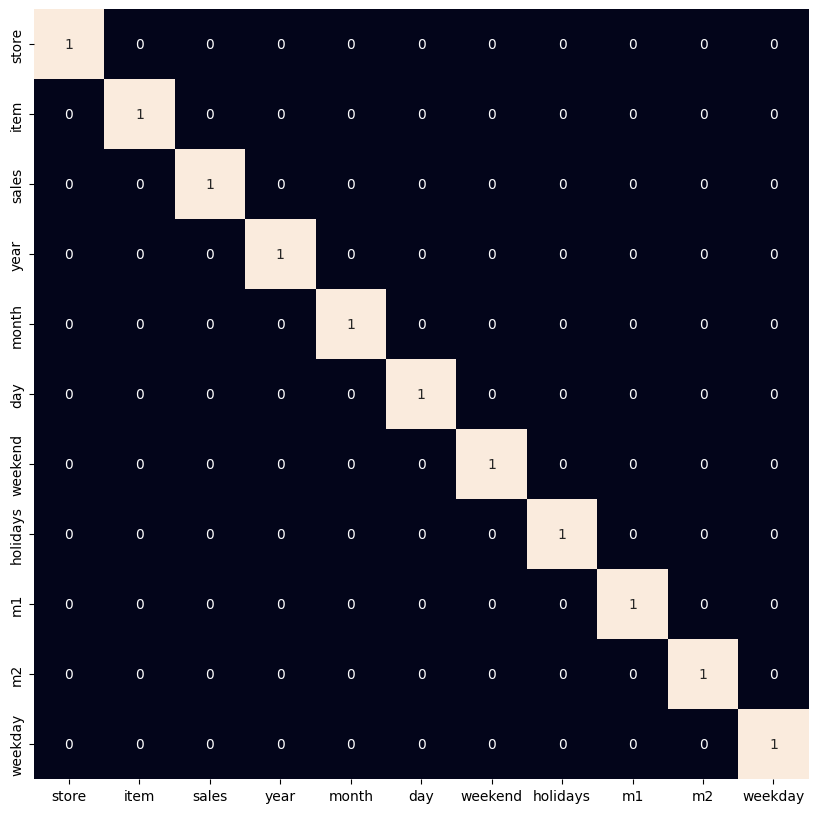

In [36]:
# We can observe that the distribution is right skewed and the dataset contains outliers.

# Now, let's check the correlation between the features of the data and added a filter to identify only the highly correlated features. For computing the correlation between the features of the dataset, we use corr() function.
plt.figure(figsize=(10, 10))
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [37]:
# As we observed earlier let's remove the outliers which are present in the data.
df = df[df['sales']<140]


# Model Training

In [38]:
# Now, we will separate the features and target variables and split them into training and the testing data by using which we will select the model which is performing best on the validation data.
features = df.drop(['sales', 'year'], axis=1)
target = df['sales'].values


X_train, X_val, Y_train, Y_val = train_test_split(features, target,
                                                  test_size = 0.05,
                                                  random_state=22)
X_train.shape, X_val.shape

((861170, 9), (45325, 9))

In [39]:
# Normalizing the data before feeding it into machine learning models helps us to achieve stable and fast training.
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [40]:
# We have split our data into training and validation data also the normalization of the data has been done. Now let's train machine learning models and select the best out of them using the validation dataset.

# For this implementation, we have used Linear Regression, XGBoost, Lasso Regression and Ridge Regression.
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()]

for i in range(4):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()

LinearRegression() : 
Training Error :  20.903011639935794
Validation Error :  20.971878842602617

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  6.9172892570495605
Validation Error :  6.9274091720581055

Lasso() : 
Training Error :  21.015028699769758
Validation Error :  21.

In [41]:
# After training and evaluating the models, we observe that XGBoost performs the best with the lowest validation error. This demonstrates the power of ensemble methods in capturing complex patterns in sales data.